<a href="https://colab.research.google.com/github/AleT08/cnn_architecture_optimisation/blob/main/CNN_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
!pip install medmnist
import medmnist
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from medmnist import INFO, Evaluator
from medmnist.dataset import BreastMNIST



In [115]:
# Dataset info
data_flag = 'breastmnist'
info = INFO[data_flag]

# Transform (convert to tensor + normalize)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])



# Load datasets
train_dataset = BreastMNIST(split='train', transform=transform, download=True)
val_dataset   = BreastMNIST(split='val', transform=transform, download=True)
test_dataset  = BreastMNIST(split='test', transform=transform, download=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)


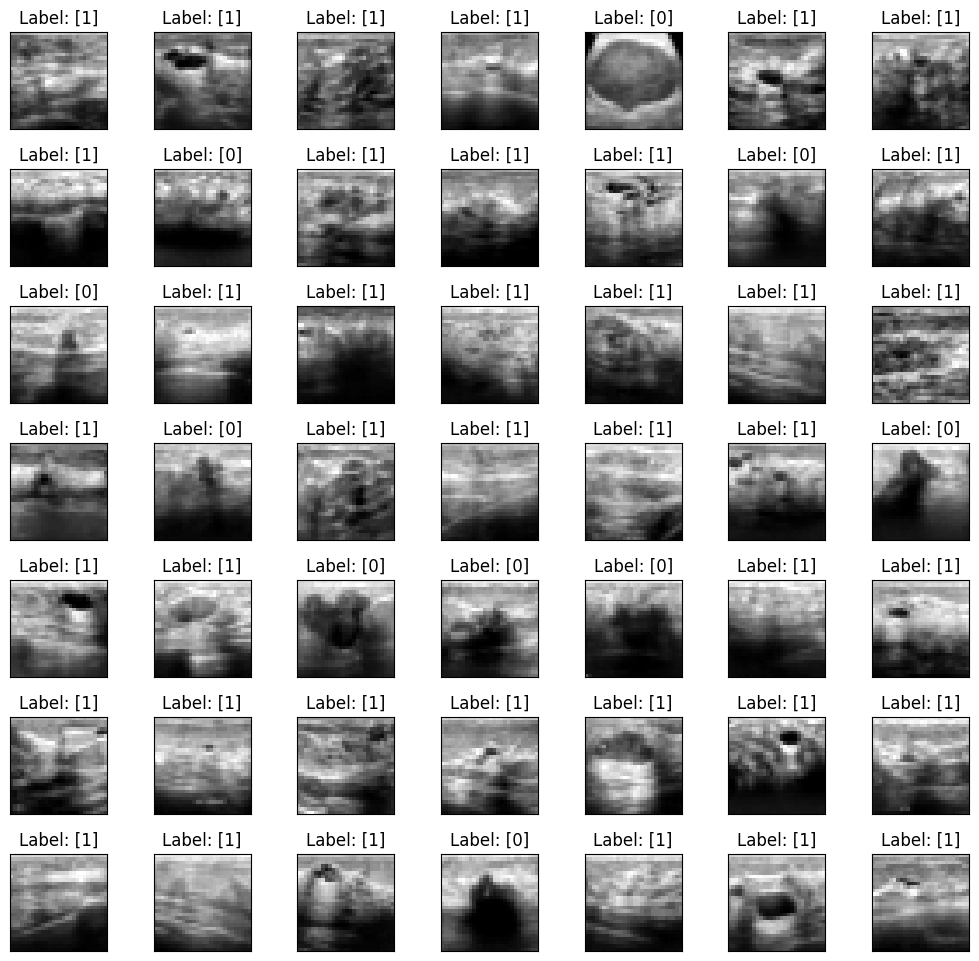

In [116]:
image, label = train_dataset[0]

plt.figure(figsize=(10, 10))
for i in range(49):
    plt.subplot(7, 7, i + 1)
    plt.tight_layout()
    plt.xticks([])
    plt.yticks([])
    plt.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    plt.title(f"Label: {train_dataset[i][1]}")
plt.show()

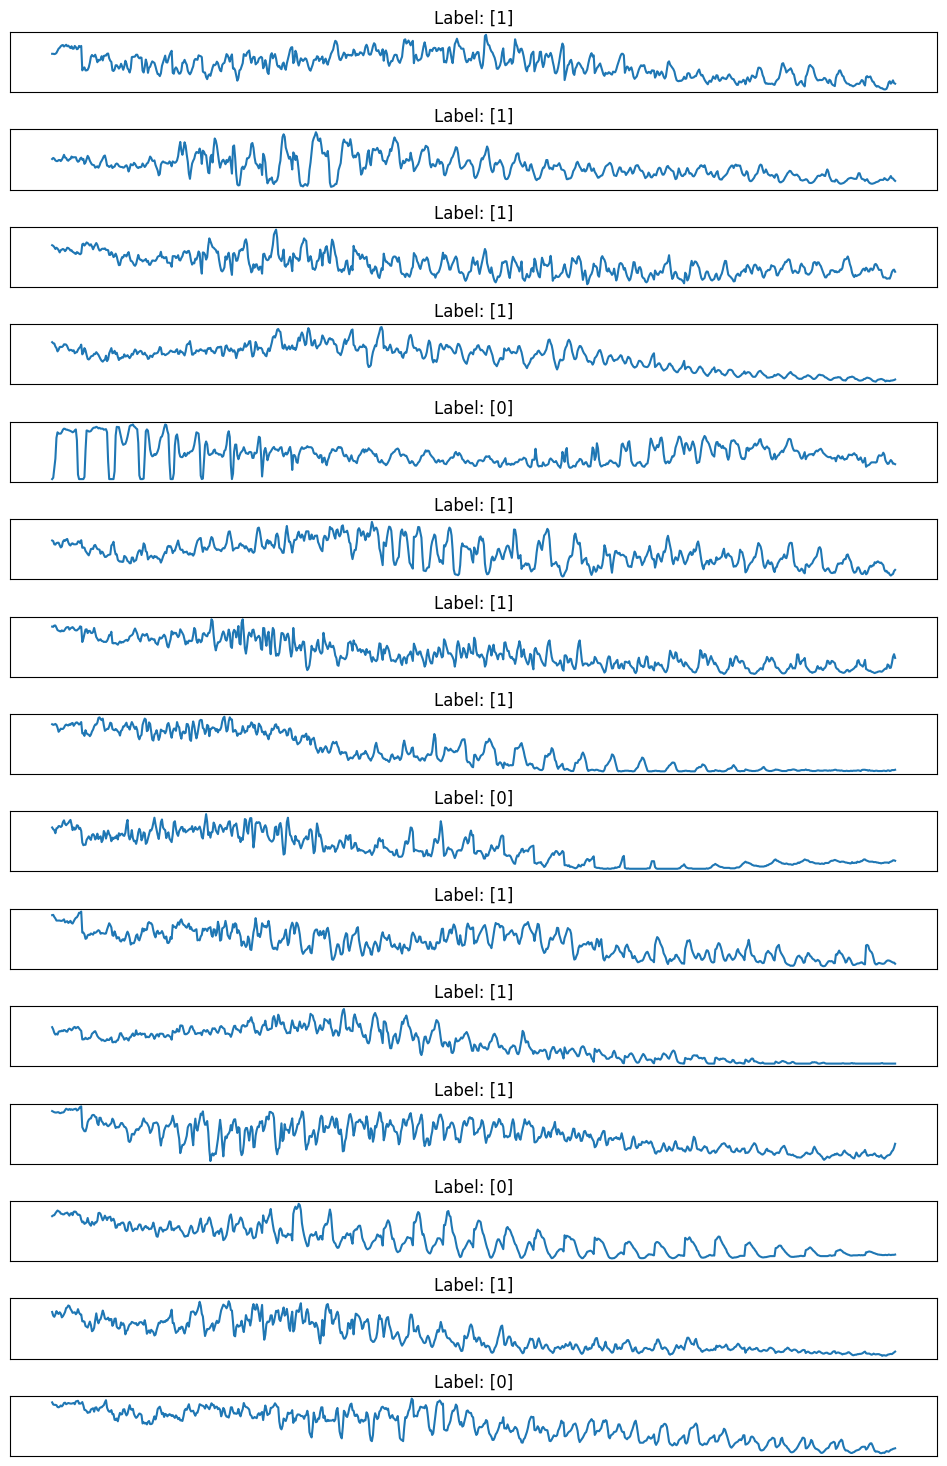

In [117]:
plt.figure(figsize=(10, 15))
for i in range(15):
    plt.subplot(15, 1, i + 1)
    plt.tight_layout()
    plt.xticks([])
    plt.yticks([])
    plt.plot(train_dataset[i][0].flatten())
    plt.title(f"Label: {train_dataset[i][1]}")
plt.show()

In [118]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1
            )
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
            )


        self.flatten = nn.Flatten()
        # 16 × 14 × 14 = 3136
        self.fc1 = nn.Linear(16 * 14 * 14, 128)
        self.relu2 = nn.ReLU()
        # Input features: 128
        # Binary output layer
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        # Apply the first convolutional block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Flatten the output for the fully connected layers
        x = self.flatten(x)

        # Apply the fully connected layers
        x = self.fc1(x)
        x = self.relu2(x)
        x = self.fc2(x)

        return x

$$loss=−[ylog(σ(z))+(1−y)log(1−σ(z))]$$

In [119]:
# Calculate class weights for imbalanced dataset
class_counts = np.bincount(train_dataset.labels.squeeze())

# For BCEWithLogitsLoss, we use pos_weight for handling class imbalance.
# pos_weight = total_negative_samples / total_positive_samples
# Assuming class 0 is negative and class 1 is positive.
pos_weight = torch.tensor([float(class_counts[0]) / class_counts[1]])

# Instantiate the model
model = SimpleCNN()

# Initialize the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Initialize the loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# IMPORTANT NOTE: For BCEWithLogitsLoss, the SimpleCNN model's final output layer
# (self.fc2) should produce a single logit (e.g., nn.Linear(128, 1)),
# not two. Please ensure the SimpleCNN class definition in cell 'sum5dDQlx8rE'
# is updated accordingly.

In [120]:
# model = SimpleCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Reduced epochs to avoid long wait times
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        # Forward pass
        outputs = model(images)
        # Reshape labels to match outputs and convert to float
        # Corrected: Use labels.float() directly as labels from DataLoader are likely [batch_size, 1]
        loss = criterion(outputs, labels.float())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/3, Loss: 0.3533
Epoch 2/3, Loss: 0.3311
Epoch 3/3, Loss: 0.3045


In [121]:
image, label = test_dataset[0]

with torch.no_grad():
    probs = model(image.unsqueeze(0))

probs = probs.numpy()[0]

print("Probabilities:", probs)
print("Predicted digit:", np.argmax(probs))
print("True digit:", label)

Probabilities: [-0.68310106]
Predicted digit: 0
True digit: [0]


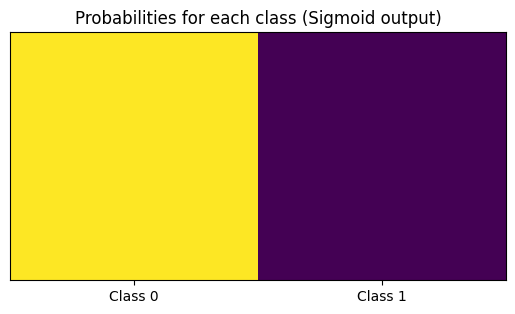

In [122]:
# The 'probs' variable currently holds a single logit value from the model output
# To display probabilities for two classes (binary classification), we need to:
# 1. Apply sigmoid to get the probability of the positive class.
# 2. Calculate the probability of the negative class (1 - positive probability).
import torch

# Ensure 'probs' is treated as a scalar logit for sigmoid calculation
logit_value = probs.item()

# Calculate probabilities for class 0 (negative) and class 1 (positive)
prob_positive = torch.sigmoid(torch.tensor(logit_value)).item()
prob_negative = 1 - prob_positive

# Create a 1x2 array for plotting (probability of class 0, probability of class 1)
display_probs = np.array([prob_negative, prob_positive])

plt.imshow(display_probs.reshape(1,2))
plt.yticks([])
plt.xticks(range(2), ['Class 0', 'Class 1'])
plt.title("Probabilities for each class (Sigmoid output)")
plt.show()

In [123]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [124]:
y_pred = []
y_test = []

model.eval()  # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculations during inference
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1);

        y_pred.extend(predicted.cpu().numpy())
        y_test.extend(labels.cpu().numpy())

# Convert to numpy arrays for sklearn metrics
y_pred = np.array(y_pred)
y_test = np.array(y_test)

print("y_test shape:", y_test.shape)
print("y_pred shape:", y_pred.shape)

y_test shape: (156, 1)
y_pred shape: (156,)


In [125]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.2692307692307692


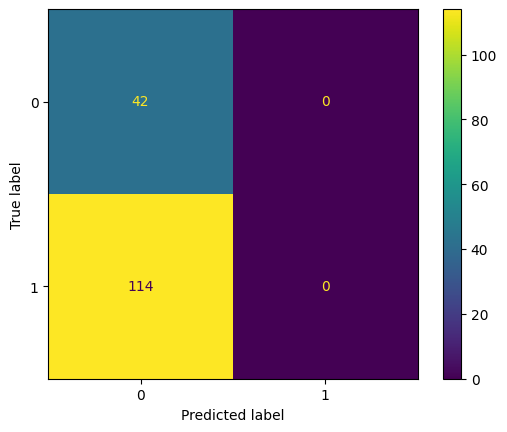

In [126]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()